In [1]:
import pandas as pd

In [2]:
hospitals = pd.read_csv("../Data/cleaned_tennessee_hospitals_final.csv")

In [3]:
hospitals.head()

,facility_id,facility_name,county,hospital_type,hospital_ownership,emergency_services,county.1
0,440002,JACKSON-MADISON COUNTY GENERAL HOSPITAL,Madison,Acute Care Hospitals,Government - Hospital District Or Authority,Yes,Madison
1,440003,HIGHPOINT HEALTH-SUMNER WITH ASCENSION SAINT T...,Sumner,Acute Care Hospitals,Proprietary,Yes,Sumner
2,440006,TRISTAR SKYLINE MEDICAL CENTER,Davidson,Acute Care Hospitals,Voluntary Non-Profit - Private,Yes,Davidson
3,440007,UNITY MEDICAL CENTER,Coffee,Acute Care Hospitals,Voluntary Non-Profit - Private,Yes,Coffee
4,440008,HENDERSON COUNTY COMMUNITY HOSPITAL,Henderson,Acute Care Hospitals,Proprietary,Yes,Henderson


In [4]:
pulse = pd.read_csv("../Data/cleaned_pulse_data_final.csv")

In [5]:
pulse.head()

,county,fips,value_dollars,rank_us,county.1
0,Lake County,47095,39522,3127,Lake County
1,Hancock County,47067,48165,3092,Hancock County
2,Grundy County,47061,52772,3029,Grundy County
3,Scott County,47151,53423,3022,Scott County
4,Cocke County,47029,54527,3001,Cocke County


In [6]:
# 1.)	Do lower-income Tennessee counties have fewer hospitals per capita than higher-income counties?

In [7]:
hospital_counts = hospitals.groupby("county").size().reset_index(name="hospital_count")

In [8]:
hospital_counts.head()

,county,hospital_count
0,Anderson,2
1,Bedford,1
2,Benton,1
3,Bledsoe,1
4,Blount,1


In [9]:
pulse["county"] = pulse["county"].str.replace("County", "", regex=False)

In [10]:
pulse["county"] = pulse["county"].str.replace("County", "", regex=False).str.strip()

In [11]:
pulse.head()

,county,fips,value_dollars,rank_us,county.1
0,Lake,47095,39522,3127,Lake County
1,Hancock,47067,48165,3092,Hancock County
2,Grundy,47061,52772,3029,Grundy County
3,Scott,47151,53423,3022,Scott County
4,Cocke,47029,54527,3001,Cocke County


In [12]:
merged = pulse.merge(hospital_counts, on="county", how="left")

In [13]:
merged.head()

,county,fips,value_dollars,rank_us,county.1,hospital_count
0,Lake,47095,39522,3127,Lake County,NaN
1,Hancock,47067,48165,3092,Hancock County,1.0
2,Grundy,47061,52772,3029,Grundy County,NaN
3,Scott,47151,53423,3022,Scott County,1.0
4,Cocke,47029,54527,3001,Cocke County,1.0


In [14]:
merged["hospital_count"] = merged["hospital_count"].fillna(0)

In [15]:
merged.describe()

,fips,value_dollars,rank_us,hospital_count
count,95.000000,95.000000,95.000000,95.000000
mean,47095.000000,74006.157895,2037.178947,1.273684
std,55.136195,14877.001490,761.924816,2.002350
min,47001.000000,39522.000000,28.000000,0.000000
25%,47048.000000,65670.000000,1493.000000,0.000000
50%,47095.000000,71662.000000,2233.000000,1.000000
75%,47142.000000,81434.500000,2588.000000,1.000000
max,47189.000000,153397.000000,3127.000000,14.000000


In [16]:
merged["income_group"] = pd.qcut(
    merged["value_dollars"],
    q=4,
    labels=["low", "Lower-Mid", "Upper-Mid", "High"]
)

In [17]:
merged[["county", "value_dollars", "income_group"]].head()

,county,value_dollars,income_group
0,Lake,39522,low
1,Hancock,48165,low
2,Grundy,52772,low
3,Scott,53423,low
4,Cocke,54527,low


In [18]:
merged.groupby("income_group")["hospital_count"].mean()

C:\Users\rache\AppData\Local\Temp\ipykernel_20684\1063647245.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged.groupby("income_group")["hospital_count"].mean()


income_group
low          0.500000
Lower-Mid    0.875000
Upper-Mid    1.565217
High         2.166667
Name: hospital_count, dtype: float64

C:\Users\rache\AppData\Local\Temp\ipykernel_20684\3567155461.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged.groupby("income_group")["hospital_count"].mean().plot(kind="bar")


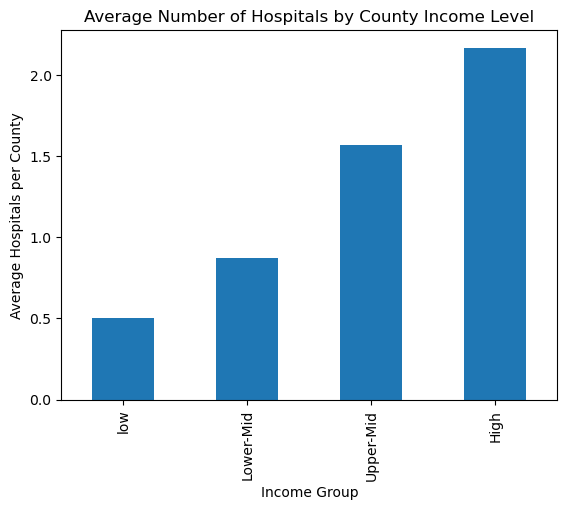

In [19]:
import matplotlib.pyplot as plt

merged.groupby("income_group")["hospital_count"].mean().plot(kind="bar")
plt.title("Average Number of Hospitals by County Income Level")
plt.xlabel("Income Group")
plt.ylabel("Average Hospitals per County")

plt.show()


In [20]:
merged["value_dollars"].corr(merged["hospital_count"])

np.float64(0.32822871787793445)

In [21]:
# 2.) Are lower-income? counties more likely to be served by for-profit hospitals than non-profit hospitals?

In [22]:
hospitals["hospital_ownership"].value_counts()

hospital_ownership
Proprietary                                    44
Voluntary Non-Profit - Private                 31
Government - Hospital District Or Authority    12
Government - Local                             12
Voluntary Non-Profit - Other                   11
Voluntary Non-Profit - Church                   7
Veterans Health Administration                  4
Government - State                              2
Name: count, dtype: int64

In [23]:
hospitals["ownership_type"] = hospitals["hospital_ownership"].replace({
    "Proprietary": "For-Profit",
    "Voluntary Non-Profit - Private": "Non-Profit",
    "Voluntary Non-Profit - Other": "Non-Profit",
    "Voluntary Non-Profit - Church": "Non-Profit"
})

In [24]:
hospitals["ownership_type"].value_counts()

ownership_type
Non-Profit                                     49
For-Profit                                     44
Government - Hospital District Or Authority    12
Government - Local                             12
Veterans Health Administration                  4
Government - State                              2
Name: count, dtype: int64

In [25]:
ownership_counts = hospitals.groupby(["county", "ownership_type"]).size().reset_index(name="count")

In [26]:
ownership_counts.head()

,county,ownership_type,count
0,Anderson,Non-Profit,2
1,Bedford,For-Profit,1
2,Benton,Government - Hospital District Or Authority,1
3,Bledsoe,Government - Hospital District Or Authority,1
4,Blount,Government - Local,1


In [27]:
ownership_merged = pulse.merge(ownership_counts, on="county", how="left")

In [28]:
ownership_merged.head()

,county,fips,value_dollars,rank_us,county.1,ownership_type,count
0,Lake,47095,39522,3127,Lake County,NaN,NaN
1,Hancock,47067,48165,3092,Hancock County,Non-Profit,1.0
2,Grundy,47061,52772,3029,Grundy County,NaN,NaN
3,Scott,47151,53423,3022,Scott County,For-Profit,1.0
4,Cocke,47029,54527,3001,Cocke County,For-Profit,1.0


In [29]:
ownership_merged["income_group"] = pd.qcut(
    ownership_merged["value_dollars"],
    4,
    labels=["Low", "Lower-Mid", "Upper-Mid", "High"]
)

In [30]:
ownership_merged[["county","value_dollars","income_group"]].head()

,county,value_dollars,income_group
0,Lake,39522,Low
1,Hancock,48165,Low
2,Grundy,52772,Low
3,Scott,53423,Low
4,Cocke,54527,Low


In [31]:
ownership_summary = ownership_merged.groupby(["income_group", "ownership_type"])["count"].sum()

C:\Users\rache\AppData\Local\Temp\ipykernel_20684\1058976546.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ownership_summary = ownership_merged.groupby(["income_group", "ownership_type"])["count"].sum()


In [32]:
ownership_summary

income_group  ownership_type                             
Low           For-Profit                                      6.0
              Government - Hospital District Or Authority     2.0
              Government - Local                              3.0
              Government - State                              0.0
              Non-Profit                                      7.0
              Veterans Health Administration                  0.0
Lower-Mid     For-Profit                                      6.0
              Government - Hospital District Or Authority     2.0
              Government - Local                              4.0
              Government - State                              0.0
              Non-Profit                                     10.0
              Veterans Health Administration                  0.0
Upper-Mid     For-Profit                                     13.0
              Government - Hospital District Or Authority     4.0
              Gove

In [33]:
ownership_table = ownership_summary.unstack()
ownership_table

ownership_type,For-Profit,Government - Hospital District Or Authority,Government - Local,Government - State,Non-Profit,Veterans Health Administration
income_group,,,,,,
Low,6.0,2.0,3.0,0.0,7.0,0.0
Lower-Mid,6.0,2.0,4.0,0.0,10.0,0.0
Upper-Mid,13.0,4.0,3.0,0.0,15.0,2.0
High,18.0,4.0,2.0,2.0,16.0,2.0


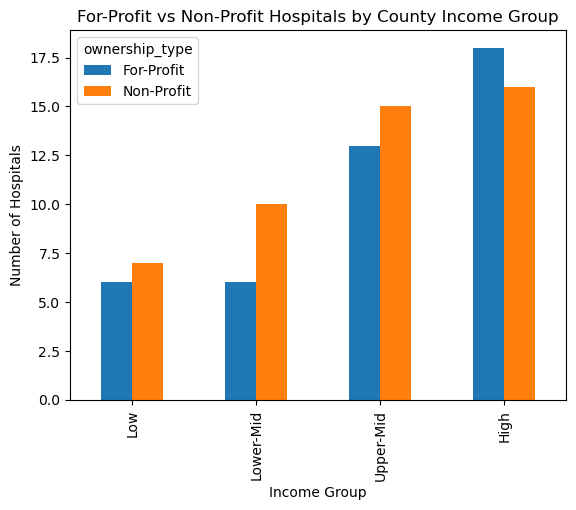

In [34]:
import matplotlib.pyplot as plt

ownership_table[["For-Profit", "Non-Profit"]].plot(kind="bar")

plt.title("For-Profit vs Non-Profit Hospitals by County Income Group")
plt.xlabel("Income Group")
plt.ylabel("Number of Hospitals")

plt.show()

In [35]:
# 3.) Do rural Tennessee counties have fewer emergency-capable hospitals than metropolitan counties??

In [36]:
hospitals["emergency_services"].value_counts()

emergency_services
Yes    100
No      23
Name: count, dtype: int64

In [37]:
emergency_counts = hospitals[hospitals["emergency_services"] == "Yes"].groupby("county").size().reset_index(name="emergency_hospitals")

In [38]:
emergency_counts.head()

,county,emergency_hospitals
0,Anderson,1
1,Bedford,1
2,Benton,1
3,Bledsoe,1
4,Blount,1


In [39]:
emergency_merged = pulse.merge(emergency_counts, on="county", how="left")

In [40]:
emergency_merged.head()

,county,fips,value_dollars,rank_us,county.1,emergency_hospitals
0,Lake,47095,39522,3127,Lake County,NaN
1,Hancock,47067,48165,3092,Hancock County,1.0
2,Grundy,47061,52772,3029,Grundy County,NaN
3,Scott,47151,53423,3022,Scott County,1.0
4,Cocke,47029,54527,3001,Cocke County,1.0


In [41]:
emergency_merged["emergency_hospitals"] = emergency_merged["emergency_hospitals"].fillna(0)

In [42]:
emergency_merged["emergency_hospitals"].describe()

count    95.000000
mean      1.031579
std       1.410090
min       0.000000
25%       0.000000
50%       1.000000
75%       1.000000
max      10.000000
Name: emergency_hospitals, dtype: float64

In [43]:
emergency_merged["income_group"] = pd.qcut(
    emergency_merged["value_dollars"],
    4,
    labels=["Low", "Lower-Mid", "Upper-Mid", "High"]
)

In [44]:
emergency_merged[["county","value_dollars","income_group","emergency_hospitals"]].head()

,county,value_dollars,income_group,emergency_hospitals
0,Lake,39522,Low,0.0
1,Hancock,48165,Low,1.0
2,Grundy,52772,Low,0.0
3,Scott,53423,Low,1.0
4,Cocke,54527,Low,1.0


In [45]:
emergency_by_income = emergency_merged.groupby("income_group")["emergency_hospitals"].mean()
emergency_by_income

C:\Users\rache\AppData\Local\Temp\ipykernel_20684\940711058.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  emergency_by_income = emergency_merged.groupby("income_group")["emergency_hospitals"].mean()


income_group
Low          0.50000
Lower-Mid    0.75000
Upper-Mid    1.26087
High         1.62500
Name: emergency_hospitals, dtype: float64

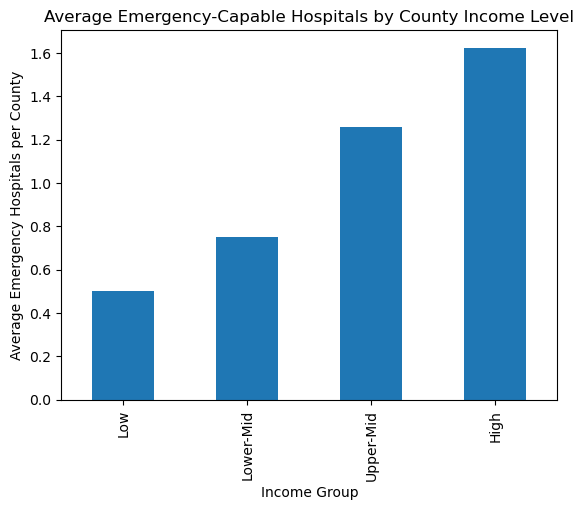

In [46]:
import matplotlib.pyplot as plt

emergency_by_income.plot(kind="bar")

plt.title("Average Emergency-Capable Hospitals by County Income Level")
plt.xlabel("Income Group")
plt.ylabel("Average Emergency Hospitals per County")

plt.show()

In [47]:
hospitals["government_hospital"] = hospitals["ownership_type"].str.contains("Government|Veterans")

In [48]:
hospitals[["ownership_type","government_hospital"]].head()

,ownership_type,government_hospital
0,Government - Hospital District Or Authority,True
1,For-Profit,False
2,Non-Profit,False
3,Non-Profit,False
4,For-Profit,False


In [49]:
# 4.) Are lower-income counties more likely to rely on government-run hospitals?

In [50]:
government_counts = hospitals[hospitals["government_hospital"] == True].groupby("county").size().reset_index(name="government_hospitals")

In [51]:
government_counts.head()

,county,government_hospitals
0,Benton,1
1,Bledsoe,1
2,Blount,1
3,Claiborne,1
4,Davidson,3


In [52]:
government_merged = pulse.merge(government_counts, on="county", how="left")

In [53]:
government_merged.head()

,county,fips,value_dollars,rank_us,county.1,government_hospitals
0,Lake,47095,39522,3127,Lake County,NaN
1,Hancock,47067,48165,3092,Hancock County,NaN
2,Grundy,47061,52772,3029,Grundy County,NaN
3,Scott,47151,53423,3022,Scott County,NaN
4,Cocke,47029,54527,3001,Cocke County,NaN


In [54]:
government_merged["government_hospitals"] = government_merged["government_hospitals"].fillna(0)

In [55]:
government_merged["government_hospitals"].describe()

count    95.000000
mean      0.315789
std       0.623360
min       0.000000
25%       0.000000
50%       0.000000
75%       0.500000
max       3.000000
Name: government_hospitals, dtype: float64

In [56]:
government_merged["income_group"] = pd.qcut(
    government_merged["value_dollars"],
    4,
    labels=["Low", "Lower-Mid", "Upper-Mid", "High"]
)

In [57]:
government_by_income = government_merged.groupby("income_group")["government_hospitals"].mean()
government_by_income

C:\Users\rache\AppData\Local\Temp\ipykernel_20684\502284981.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  government_by_income = government_merged.groupby("income_group")["government_hospitals"].mean()


income_group
Low          0.208333
Lower-Mid    0.208333
Upper-Mid    0.347826
High         0.500000
Name: government_hospitals, dtype: float64

In [58]:
summary_table = {
    "Analysis": [
        "Hospitals vs Income Correlation",
        "For-Profit vs Non-Profit Pattern",
        "Emergency Hospitals vs Income",
        "Government Hospitals vs Income"
    ],
    "Key Result": [
        "Moderate positive correlation (≈0.33)",
        "Non-profits slightly more common in lower-income counties",
        "Higher-income counties have more emergency hospitals",
        "Government hospitals slightly more common in higher-income counties"
    ]
}

import pandas as pd
pd.DataFrame(summary_table)

,Analysis,Key Result
0,Hospitals vs Income Correlation,Moderate positive correlation (≈0.33)
1,For-Profit vs Non-Profit Pattern,Non-profits slightly more common in lower-inco...
2,Emergency Hospitals vs Income,Higher-income counties have more emergency hos...
3,Government Hospitals vs Income,Government hospitals slightly more common in h...


In [60]:
merged.to_csv("../Data/tennessee_hospital_analysis_for_powerbi.csv", index=False)